# **Introduction: AI Workplace Productivity**

The **AI Workplace Productivity** dataset explores the intersection of artificial intelligence, employee work habits, and overall productivity within a modern professional environment. It is a comprehensive collection of 4,500 employee records across various job roles (e.g., Managers, Analyst, Developer, Writer, Marketer etc...).

The **goal** of this project is to predict, as a regression task, the productivity_score of an employee in the workplace, ranging from 0 to 100, based on AI tool usage and work habits.

**Dataset Source:** Kaggle - AI Workplace Productivity Dataset

## **Importing Modules**

In [46]:
pip install matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
pip install pandas



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
!pip install missingno==0.5.2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [49]:
# Core libraries
import pandas as pd
import numpy as np
import itertools
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## **Data Loading**

Upload the feature and target Files and Merge the Data to make a unique Dataset with both feature variables and Target variables.

In [50]:
# Upload the files
features = pd.read_csv('ai_productivity_features.csv')
targets = pd.read_csv('ai_productivity_targets.csv')

# Merge the data 
dataset = pd.merge(features, targets, on='Employee_ID', how='inner')

# The final dataset 
dataset

,Employee_ID,job_role,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,deadline_pressure_level,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score,productivity_score,burnout_risk_level
0,3c6ca882-3fa3-446b-8208-c92f3f306f06,Writer,19,11.8,28.5,19.2,1.4,High,1.9,2.3,0.20,2,7.1,4.8,10.00,81.0,High
1,02f168cc-7747-4dbd-a868-ea2cfb41e22a,Designer,4,10.8,24.1,23.3,2.6,Low,8.0,9.8,1.82,3,3.4,5.5,6.78,59.2,Medium
2,d39ce8c9-6e2a-4f86-b888-e2b5f4a18cf7,Developer,6,25.9,69.4,10.0,1.4,Medium,6.8,8.9,5.52,5,4.6,3.8,9.66,62.4,High
3,14511660-d78a-453f-9449-f17cd239ec27,Manager,20,7.9,17.2,25.1,0.2,High,3.5,8.6,1.14,5,5.6,3.9,10.00,76.8,High
4,0597f0bb-ed5a-4e35-94ac-3f0f6a5c2bc2,Developer,15,8.6,20.6,20.1,1.4,Low,5.9,5.3,2.75,10,1.0,7.4,5.38,53.7,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,05acc22b-86b7-4aa4-9b80-33b3c77a5b82,Developer,18,4.9,15.2,30.3,3.3,Low,1.4,8.1,0.10,3,8.0,6.8,5.80,93.9,Medium
4496,338e2ff5-8be0-48de-8abb-98c72f5648b3,Writer,17,20.9,49.8,10.0,2.6,High,3.1,10.6,0.10,1,5.7,4.5,10.00,81.7,High
4497,249bce23-5c4b-4671-8239-1e121109a680,Manager,7,4.8,21.1,21.0,0.6,Low,7.2,6.6,3.97,6,3.6,7.8,5.08,60.6,Medium
4498,ffc95b77-3960-4b40-908f-1275ba5bbf91,Analyst,20,6.9,12.3,28.6,1.3,Medium,8.3,8.2,0.94,6,4.5,3.6,9.83,69.8,High


### Initial feature selection

To ensure the methodological soundness and generalization capability of the regression model, a rigorous feature selection strategy was applied based on the following principle:

- Removal of Non-Informative Identifiers and Bias Sources --> We dropped the Employee_ID columnas it represents a unique identifier with no intrinsic predictive value. Its inclusion would increase the risk of overfitting by allowing the model to memorize individual observations instead of learning generalizable patterns.
- Removal of Task-Irrelevant Features --> We droppped the burnout_risk_score column as it is not directly related to the prediction objective (productivity_score).
- Prevention of Data Leakage --> We also dropped burnout_risk_level column  because it is directly derived from the target burnout score which we are not interested in.

In [51]:
# Drop Employee_ID column because it doesn't add any value to the model (avoiding overfitting)
dataset = dataset.drop(columns=['Employee_ID'])
# Drop burnout_risk_level beacuse it leads to data leakage 
dataset = dataset.drop(columns=['burnout_risk_level'])
# Drop burnout_risk_score because it is not directly related to the productivity_score
dataset = dataset.drop(columns=['burnout_risk_score'])

## **Exploratory Data Analysis (EDA)**

### **Dataset Summary and Overview**

In [52]:
# Dataset Dimensions and Information
print("\n1. DATASET DIMENSIONS AND STRUCTURE")
print("-" * 80)
print(f"Shape: {dataset.shape[0]} rows, {dataset.shape[1]} columns")
print(f"\nColumn Names and Types:")
print(dataset.dtypes)
print(f"\nMissing Values:")
print(dataset.isnull().sum())
print(f"\nMemory Usage: {dataset.memory_usage().sum() / 1024:.2f} KB")



1. DATASET DIMENSIONS AND STRUCTURE
--------------------------------------------------------------------------------
Shape: 4500 rows, 14 columns

Column Names and Types:
job_role                            str
experience_years                  int64
ai_tool_usage_hours_per_week    float64
tasks_automated_percent         float64
manual_work_hours_per_week      float64
learning_time_hours_per_week    float64
deadline_pressure_level             str
meeting_hours_per_week          float64
collaboration_hours_per_week    float64
error_rate_percent              float64
task_complexity_score             int64
focus_hours_per_day             float64
work_life_balance_score         float64
productivity_score              float64
dtype: object

Missing Values:
job_role                        0
experience_years                0
ai_tool_usage_hours_per_week    0
tasks_automated_percent         0
manual_work_hours_per_week      0
learning_time_hours_per_week    0
deadline_pressure_level         0

In [53]:
# Descriptive Statistics
print("\n\n2. STATISTICAL SUMMARY")
print("-" * 80)
print("\nDescriptive Statistics for Numeric Variables:")
print(dataset.describe().round(3))

# Analysis of categorical variables
print("\n\n3. CATEGORICAL VARIABLES ANALYSIS")
print("-" * 80)
categorical_cols = dataset.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {dataset[col].nunique()}")
    print(f"  Distribution:\n{dataset[col].value_counts()}")




2. STATISTICAL SUMMARY
--------------------------------------------------------------------------------

Descriptive Statistics for Numeric Variables:
       experience_years  ai_tool_usage_hours_per_week  \
count          4500.000                      4500.000   
mean             10.428                        10.350   
std               5.745                         5.808   
min               1.000                         0.000   
25%               6.000                         6.000   
50%              10.000                         9.700   
75%              15.000                        14.300   
max              20.000                        30.400   

       tasks_automated_percent  manual_work_hours_per_week  \
count                 4500.000                    4500.000   
mean                    25.908                      22.373   
std                     15.158                       6.466   
min                      0.000                      10.000   
25%                    

/tmp/ipykernel_4657/1682202604.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = dataset.select_dtypes(include=['object']).columns


### **Correlation Analysis**

We use the correlation matrix to gain an initial understanding of how different features in the dataset are related to one another. In particular, we want to assess whether certain variables show strong linear relationships that could impact the performance of predictive models or signal multicollinearity issues.

The correlation matrix is especially useful at this stage for two main reasons:

- **Feature Redundancy:** If two features are highly correlated, they might provide overlapping information. In such cases, we might consider removing or combining them to avoid redundancy.

- **Preliminary Feature Impact:** Although correlation does not capture causality or nonlinear relationships, it provides a quick way to see which features are likely to have the strongest linear influence on the target variable.

However, it is important to note that correlation only measures linear relationships, and does not account for more complex patterns or feature interactions. Therefore, while the correlation matrix gives valuable initial insights, it is not sufficient for a full understanding of feature importance. Additional techniques such as regression coefficient and decision tree-based feature importance are necessary for a more complete analysis.



Firstly, we analyze the data types in order to appropriately address the categorical features.



In [54]:
# Verify datatypes and if there are any null values
print("Data types and missing values:\n")
dataset.info()

Data types and missing values:

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   job_role                      4500 non-null   str    
 1   experience_years              4500 non-null   int64  
 2   ai_tool_usage_hours_per_week  4500 non-null   float64
 3   tasks_automated_percent       4500 non-null   float64
 4   manual_work_hours_per_week    4500 non-null   float64
 5   learning_time_hours_per_week  4500 non-null   float64
 6   deadline_pressure_level       4500 non-null   str    
 7   meeting_hours_per_week        4500 non-null   float64
 8   collaboration_hours_per_week  4500 non-null   float64
 9   error_rate_percent            4500 non-null   float64
 10  task_complexity_score         4500 non-null   int64  
 11  focus_hours_per_day           4500 non-null   float64
 12  work_life_balance_score       4500 non-nu

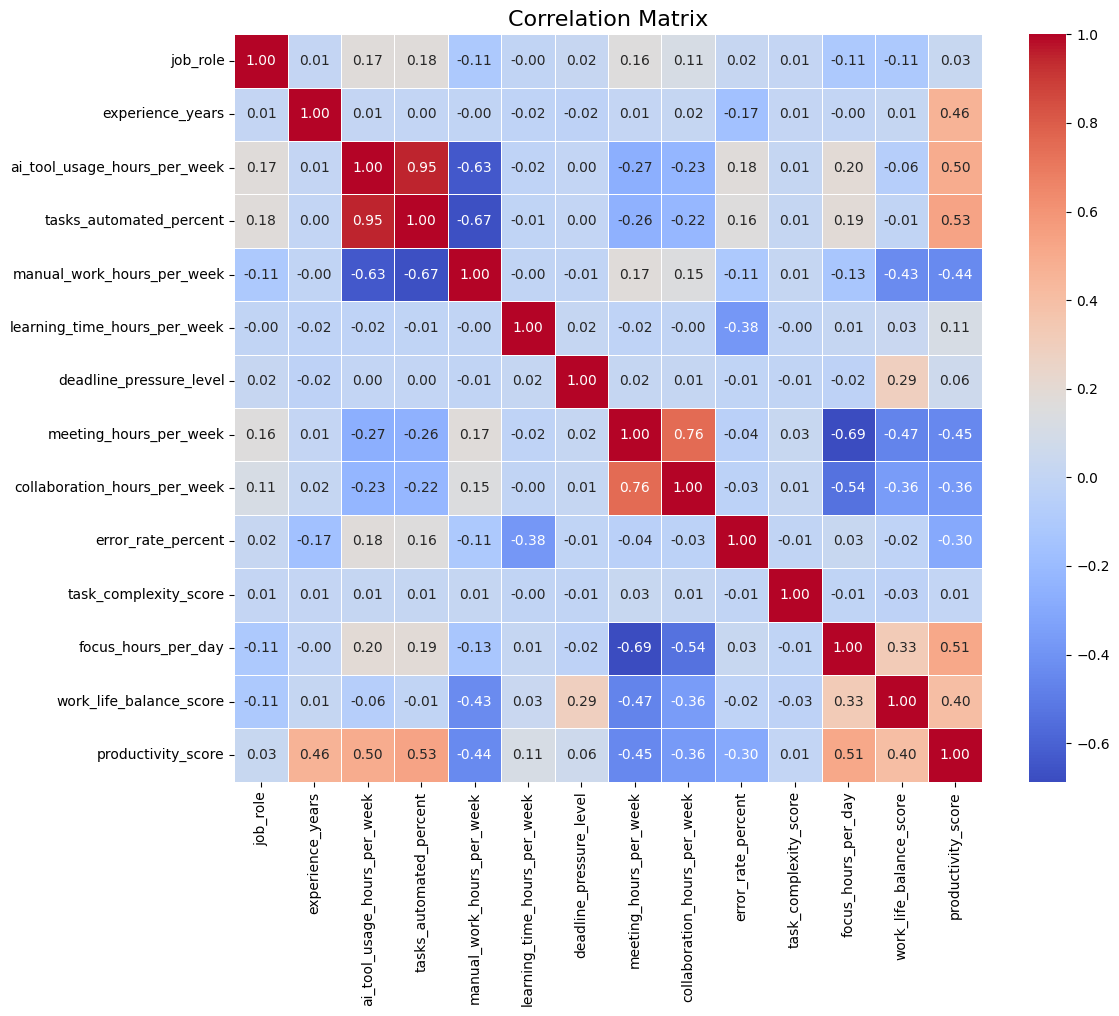

In [55]:
# We create a copy of the dataset in order to not modify the original
dataset_corr = dataset.copy()

categorical_columns = ["job_role", "deadline_pressure_level"]

label_encoder = LabelEncoder()

for column in categorical_columns:
    dataset_corr[column] = label_encoder.fit_transform(dataset_corr[column])
# label_encoder is used to encode categorical columns and convert them to numerical values

# Correlation Matrix
# Selezioniamo solo le colonne numeriche (il modello di correlazione non legge i testi)
corr_matrix = dataset_corr.corr()

# 4. Visalization of the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,              # Mostra i coefficienti nei quadratini
            cmap='coolwarm',         # Rosso = Positivo, Blu = Negativo
            fmt=".2f",               # Due decimali per precisione
            linewidths=0.5, 
            square=True)             

plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

Here we show the correlation matrix with the target variable productivity_score in descending order.

In [56]:
target_corr = corr_matrix["productivity_score"].sort_values(ascending=False)
print(target_corr)

productivity_score              1.000000
tasks_automated_percent         0.533995
focus_hours_per_day             0.514713
ai_tool_usage_hours_per_week    0.498452
experience_years                0.463643
work_life_balance_score         0.403521
learning_time_hours_per_week    0.112890
deadline_pressure_level         0.061809
job_role                        0.027989
task_complexity_score           0.005009
error_rate_percent             -0.295577
collaboration_hours_per_week   -0.364280
manual_work_hours_per_week     -0.439878
meeting_hours_per_week         -0.445299
Name: productivity_score, dtype: float64


In conclusion, the analysis indicates that no single feature exhibits a strong absolute linear correlation with the productivity_score.

**Positive Drivers**
Employees with a higher tasks_automated_percent, greater focus_hours_per_day, and increased experience_years tend to achieve noticeably higher productivity scores. A strong work_life_balance_score is also positively associated with the overall output.

**Negative Drivers**
A high number of meeting_hours_per_week, extended manual_work_hours, and an elevated error_rate_percent are associated with lower productivity levels.

These findings suggest that the relationship between the input variables and productivity is likely non-linear.

**Model Selection Implications**
Consequently, more flexible machine learning models capable of capturing non-linear relationships and complex feature interactions, such as Random Forests and Gradient Boosting methods (e.g., XGBoost) are likely to be better suited for uncovering latent patterns in this dataset than a standard linear regression approach.

### **Outlier Detection and Analysis**



5. OUTLIER DETECTION ANALYSIS
--------------------------------------------------------------------------------

Outliers Detected by IQR Method:

productivity_score:
  Lower Bound: 25.09, Upper Bound: 104.79
  Number of Outliers: 10 (0.2%)
  Range of Outliers: 20.50 to 25.00

ai_tool_usage_hours_per_week:
  Lower Bound: -6.45, Upper Bound: 26.75
  Number of Outliers: 14 (0.3%)
  Range of Outliers: 26.90 to 30.40

tasks_automated_percent:
  Lower Bound: -17.75, Upper Bound: 68.25
  Number of Outliers: 19 (0.4%)
  Range of Outliers: 68.50 to 79.90

focus_hours_per_day:
  Lower Bound: 1.35, Upper Bound: 8.15
  Number of Outliers: 79 (1.8%)
  Range of Outliers: 1.00 to 1.30

work_life_balance_score:
  Lower Bound: -1.05, Upper Bound: 10.55
  Number of Outliers: 0 (0.0%)

manual_work_hours_per_week:
  Lower Bound: 4.55, Upper Bound: 40.15
  Number of Outliers: 9 (0.2%)
  Range of Outliers: 40.40 to 43.30


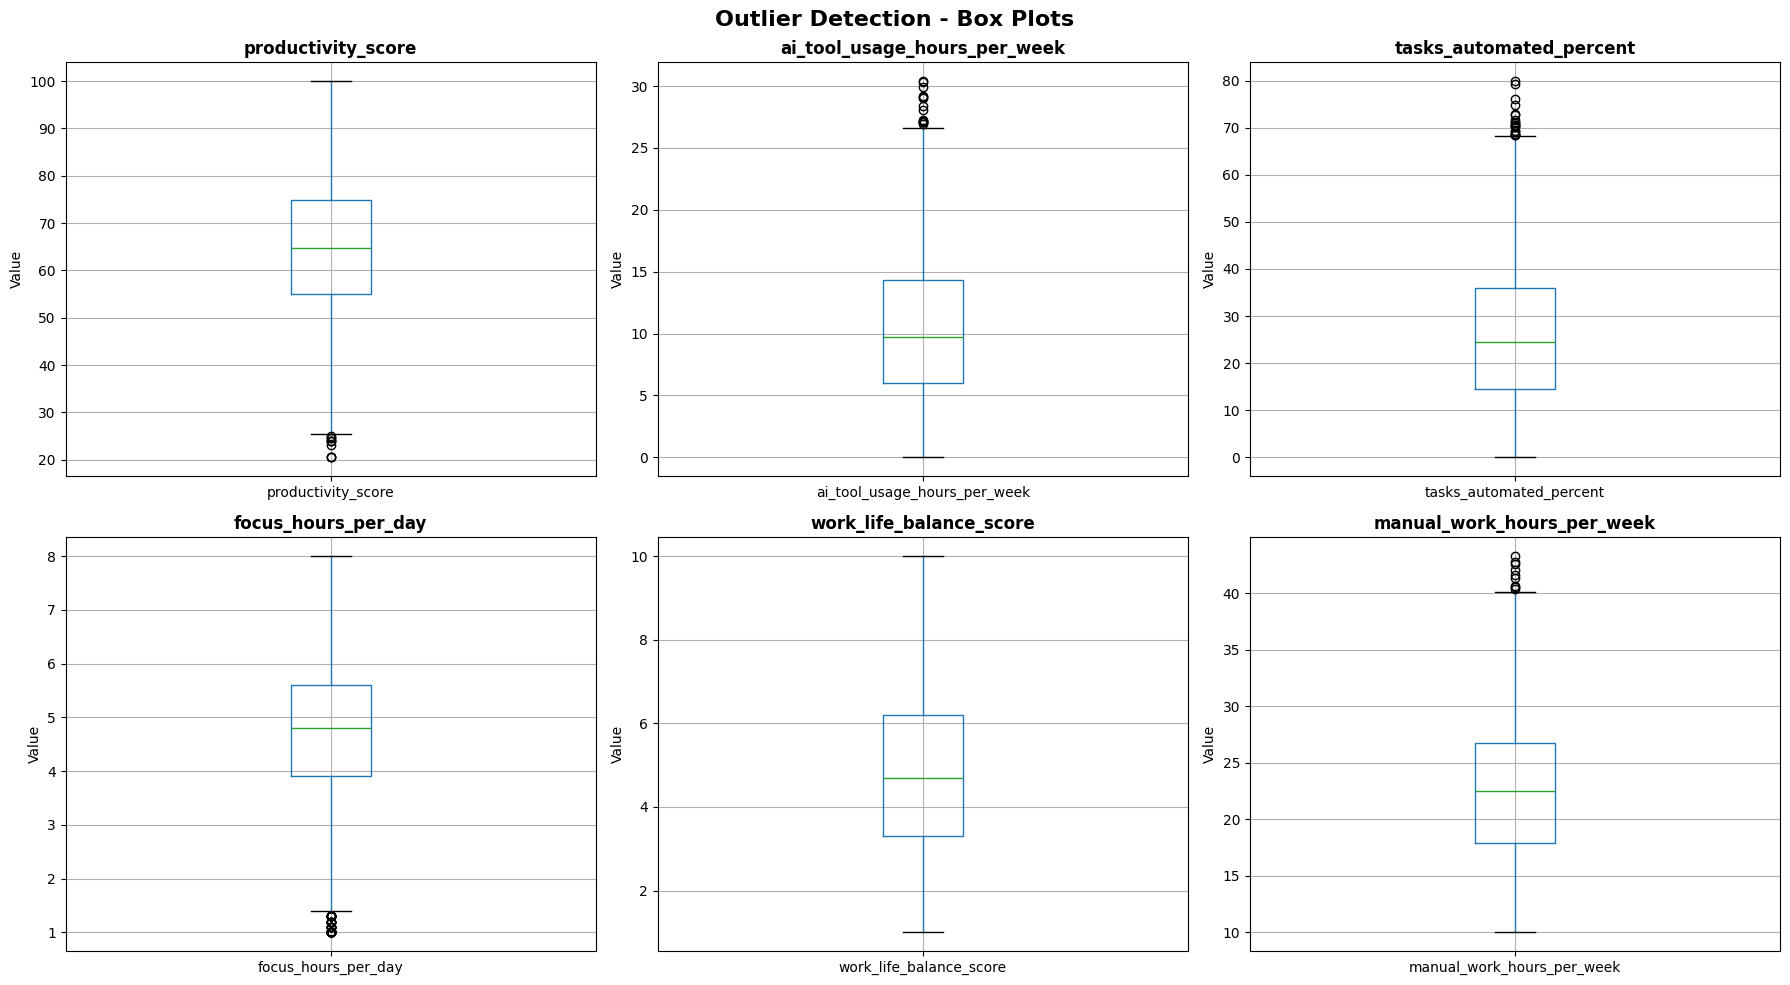



Extreme Outliers (Z-score > 3):

productivity_score: 3 extreme outliers found

ai_tool_usage_hours_per_week: 8 extreme outliers found

tasks_automated_percent: 7 extreme outliers found

manual_work_hours_per_week: 4 extreme outliers found


In [57]:
print("\n\n5. OUTLIER DETECTION ANALYSIS")
print("-" * 80)

# IQR Method for Outlier Detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Z-Score Method for Outlier Detection
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column]))
    outliers = data[z_scores > threshold]
    return outliers

# Analyze outliers for key variables
key_variables = ['productivity_score', 'ai_tool_usage_hours_per_week', 'tasks_automated_percent', 
                 'focus_hours_per_day', 'work_life_balance_score', 'manual_work_hours_per_week']

print("\nOutliers Detected by IQR Method:")
for col in key_variables:
    outliers, lower, upper = detect_outliers_iqr(dataset, col)
    print(f"\n{col}:")
    print(f"  Lower Bound: {lower:.2f}, Upper Bound: {upper:.2f}")
    print(f"  Number of Outliers: {len(outliers)} ({len(outliers)/len(dataset)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range of Outliers: {outliers[col].min():.2f} to {outliers[col].max():.2f}")

# Visualize outliers using box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(key_variables):
    dataset.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=10)

plt.tight_layout()
plt.show()

# Identify and display extreme outliers (Z-score > 3)
print("\n\nExtreme Outliers (Z-score > 3):")
for col in key_variables:
    extreme_outliers = detect_outliers_zscore(dataset, col, threshold=3)
    if len(extreme_outliers) > 0:
        print(f"\n{col}: {len(extreme_outliers)} extreme outliers found")


## **Data Visualization**

Statistiche descrittive del Target (Productivity Score):
count    4500.000000
mean       64.946600
std        14.297129
min        20.500000
25%        54.975000
50%        64.800000
75%        74.900000
max       100.000000
Name: productivity_score, dtype: float64


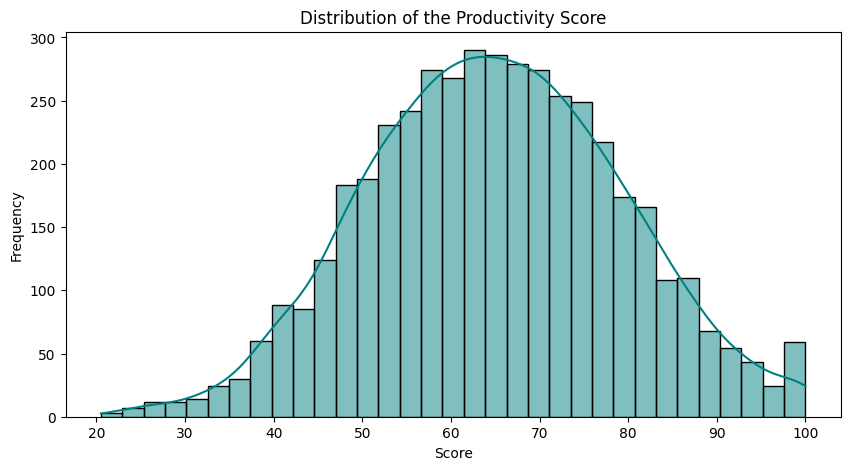

In [58]:
# Quick check of the target variable
print("Statistiche descrittive del Target (Productivity Score):")
print(dataset['productivity_score'].describe())

# Visualisation of the distribution
plt.figure(figsize=(10, 5))
sns.histplot(dataset['productivity_score'], kde=True, color='teal')
plt.title('Distribution of the Productivity Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

The results show a symmetrical distribution close to normality, confirming dataset stability and the absence of extreme outliers that could bias the model's predictions.

In addition to performing an analysis of the target variable, we also analyze the distribution of the input features to ensure that no extreme outliers are present, as such values could disproportionately influence the regression coefficients and distort the model's learned weights.

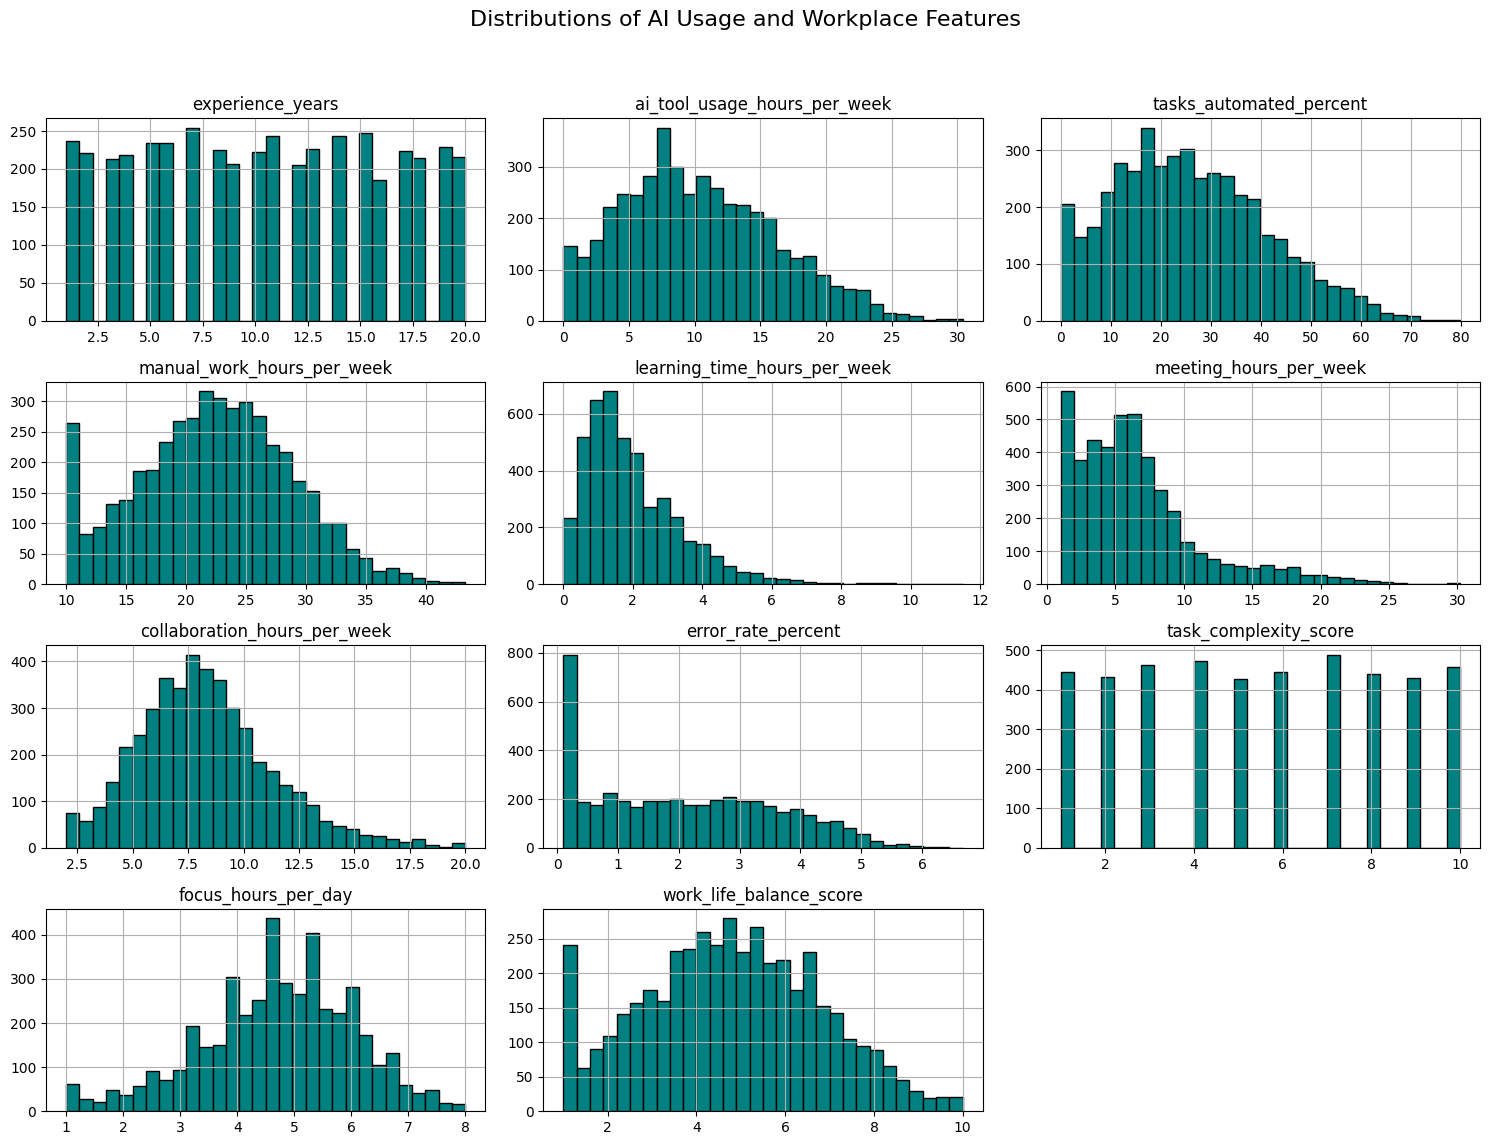

In [59]:
# Lista sintetica delle feature numeriche (escluso il target)
numerical_features = [
    "experience_years", "ai_tool_usage_hours_per_week", "tasks_automated_percent",
    "manual_work_hours_per_week", "learning_time_hours_per_week", "meeting_hours_per_week",
    "collaboration_hours_per_week", "error_rate_percent", "task_complexity_score",
    "focus_hours_per_day", "work_life_balance_score"
]

# Plot rapido di tutte le distribuzioni
dataset[numerical_features].hist(figsize=(15, 12), bins=30, layout=(4, 3), color='teal', edgecolor='black')
plt.suptitle("Distributions of AI Usage and Workplace Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

While variables such as experience_years and manual_work_hours exhibit relatively balanced and symmetric distributions, the features meeting_hours_per_week and learning_time_hours_per_week show a strongly right-skewed distribution. The vast majority of observations are concentrated at lower values, with a small number of individuals presenting extremely high values that act as potential outliers.

To address this skewness, we apply a logarithmic transformation (log1p)  to these specific features. This strategic preprocessing step allows us to:

Normalize the data: by compressing large values and expanding those close to zero, resulting in a distribution that is closer to normality.

Reduce the influence of outliers: preventing employees with unusually high meeting or training hours from disproportionately affect the regression coefficients.

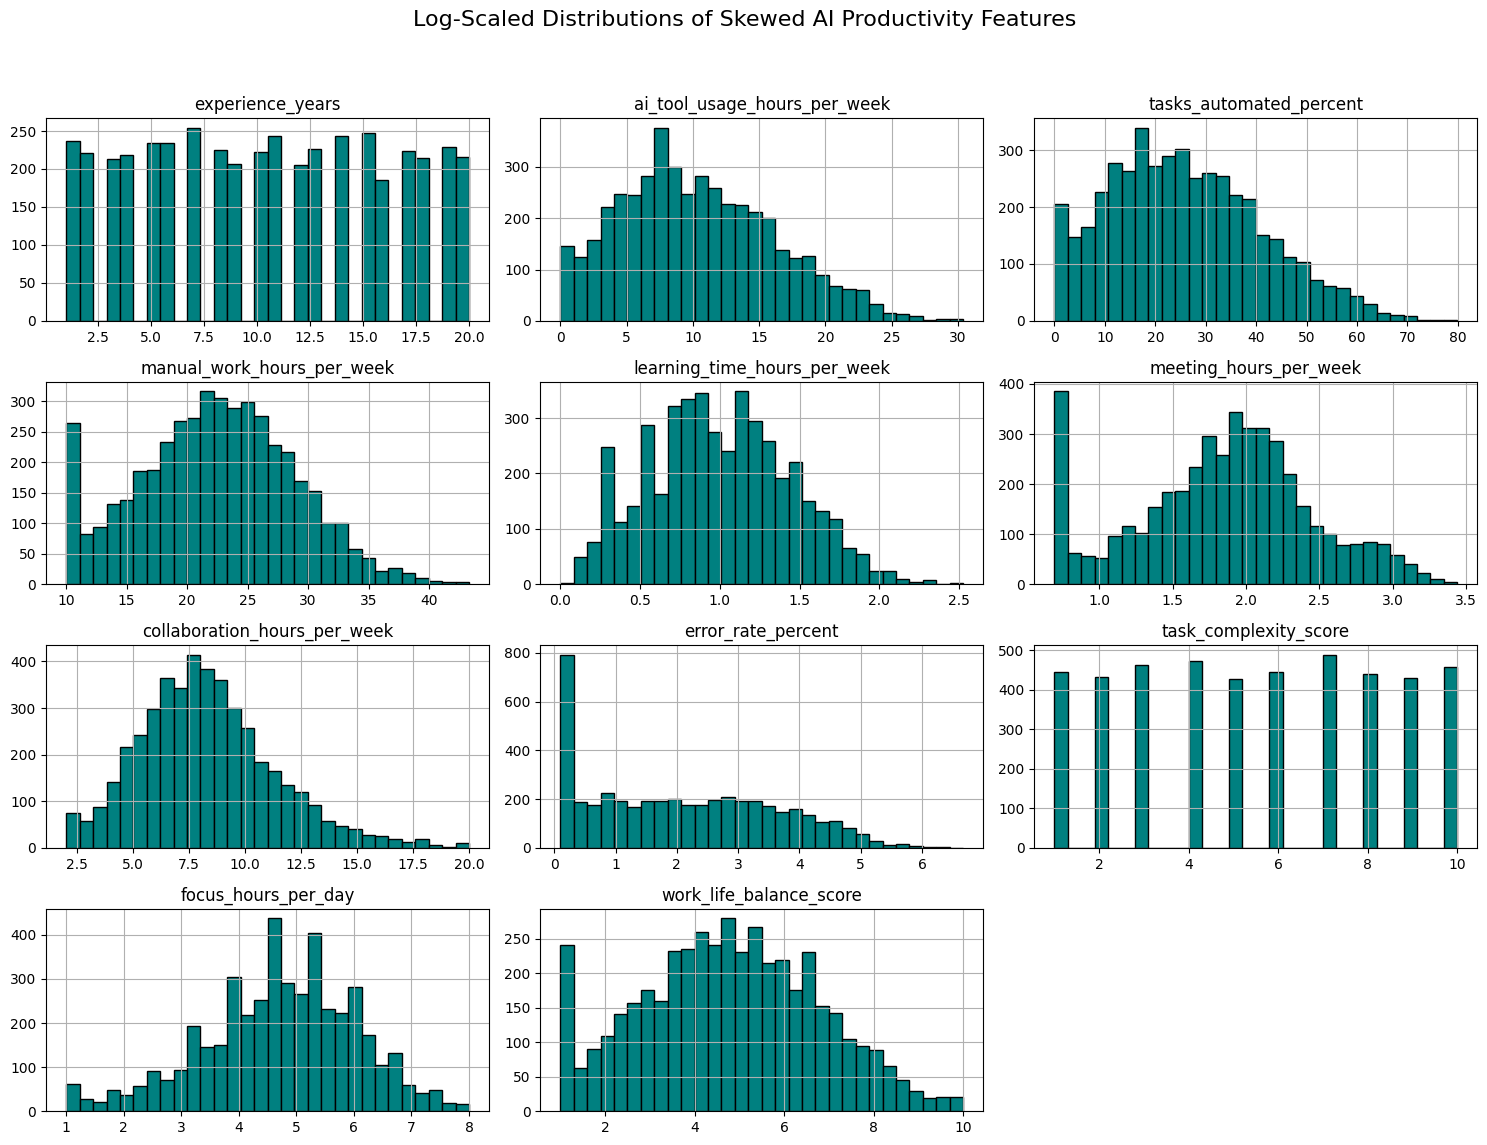

In [60]:
# Creiamo una copia per non sporcare il dataset originale durante l'analisi
dataset_log = dataset[numerical_features].copy()

# Applichiamo la trasformazione Log1p solo alle variabili identificate come "Highly Skewed"
# Nel tuo caso: meeting e learning hours
skewed_cols = ["meeting_hours_per_week", "learning_time_hours_per_week"]

dataset_log[skewed_cols] = dataset_log[skewed_cols].apply(lambda x: np.log1p(x))

# Visualizzazione finale
dataset_log.hist(figsize=(15, 12), bins=30, layout=(4, 3), color='teal', edgecolor='black')
plt.suptitle("Log-Scaled Distributions of Skewed AI Productivity Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

When we comparing the original feature distributions with those obtained after applying the log1p transformation, a moderate improvement in symmetry is observed for the variables meeting_hours_per_week and learning_time_hours_per_week.

After the transformation, these features become more balanced and comparable in scale, supporting a more robust, interpretable, and statistically reliable modeling of the target variable (productivity_score), while reducing the risk of bias and instability in the learned parameters.

## **Handling Missing Values**

First, we need to check the presence of missing values:

In [61]:
dataset.isnull().sum(axis=0)

job_role                        0
experience_years                0
ai_tool_usage_hours_per_week    0
tasks_automated_percent         0
manual_work_hours_per_week      0
learning_time_hours_per_week    0
deadline_pressure_level         0
meeting_hours_per_week          0
collaboration_hours_per_week    0
error_rate_percent              0
task_complexity_score           0
focus_hours_per_day             0
work_life_balance_score         0
productivity_score              0
dtype: int64

## **Data Preprocessing**

We define the Feautures

In [62]:
# Features that Log + Scale (Skewed)
numerical_features_log_scale = [
    "meeting_hours_per_week", "learning_time_hours_per_week"
]

# Features that just need di Scaling (Symmetric)
numerical_features_scale_only = [
    "tasks_automated_percent", "manual_work_hours_per_week", 
    "collaboration_hours_per_week", "error_rate_percent", 
    "task_complexity_score", "focus_hours_per_day", 
    "work_life_balance_score"
]

# Categorical Features 
categorical_features = ["job_role", "deadline_pressure_level"]

We define the Pipeline

In [63]:
# Pipelines
log_scale_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("log_transformer", FunctionTransformer(np.log1p, validate=True)),
    ("scaler", StandardScaler())
])

scale_only_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

### **Column Transformer**

To effectively apply the correct preprocessing steps to each type of feature, we use a ColumnTransformer. This tool allows different transformations to be applied to specific columns within a unified structure.

In [64]:
preprocessor = ColumnTransformer([
    ("log_scale", log_scale_pipeline, numerical_features_log_scale),
    ("scale_only", scale_only_pipeline, numerical_features_scale_only),
    ("categorical", categorical_pipeline, categorical_features),
], remainder='drop', verbose_feature_names_out=False)

We apply the preprocessor to the dataframe to check if it works:

In [65]:
dataset_copy = dataset.copy()

try:
    processed_data = preprocessor.fit_transform(dataset_copy)
    print("Preprocessing completed with success!")
    print("Shape of preprocessed data:", processed_data.shape)
except Exception as e:
    print("Error during preprocessing:", e)

Preprocessing completed with success!
Shape of preprocessed data: (4500, 16)


## **Model Training**

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Separazione X e y
X = dataset.drop(columns=["productivity_score"])
y = dataset["productivity_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline completa (preprocessing + model)
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_scale', ...), ('scale_only', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [67]:
# Feature numeriche
feature_names_num = numerical_features_log_scale + numerical_features_scale_only

# Feature categoriali (one-hot encoding)
categorical_ohe = model.named_steps["preprocessor"] \
    .named_transformers_["categorical"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features)

# Lista finale delle feature
feature_names = list(feature_names_num) + list(categorical_ohe)

# Controllo
print("Numero feature:", len(feature_names))

Numero feature: 16


In [68]:
import pandas as pd

importances = model.named_steps["regressor"].feature_importances_

feat_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importance.head(10))

                         feature  importance
2        tasks_automated_percent    0.333825
7            focus_hours_per_day    0.201836
5             error_rate_percent    0.168185
8        work_life_balance_score    0.087741
14   deadline_pressure_level_Low    0.046457
3     manual_work_hours_per_week    0.036301
0         meeting_hours_per_week    0.032914
4   collaboration_hours_per_week    0.030139
1   learning_time_hours_per_week    0.028089
6          task_complexity_score    0.019020


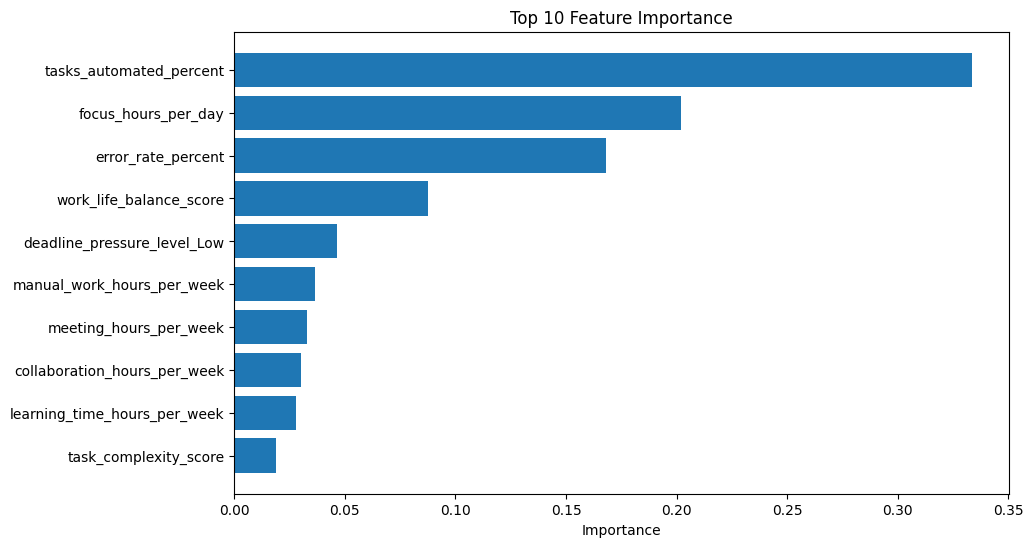

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feat_importance["feature"][:10], feat_importance["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

## **Evaluation**

In [70]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Previsioni sul test set
y_pred = model.predict(X_test)

# Metriche
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

MSE: 66.69
MAE: 6.61
R²: 0.66


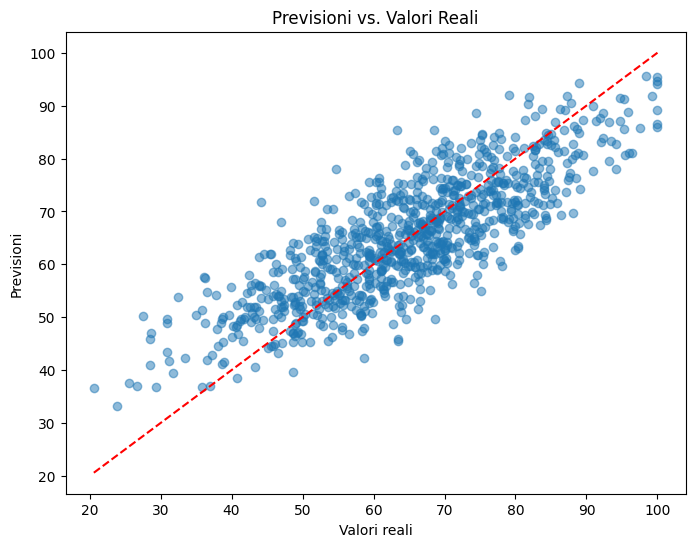

In [71]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valori reali')
plt.ylabel('Previsioni')
plt.title('Previsioni vs. Valori Reali')
plt.show()

## **Explainable AI (XAI)**

In [72]:
pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [73]:
import shap

# Trasformazione dati
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)

# Modello interno
rf_model = model.named_steps["regressor"]

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_transformed)

### **Global Evaluation**

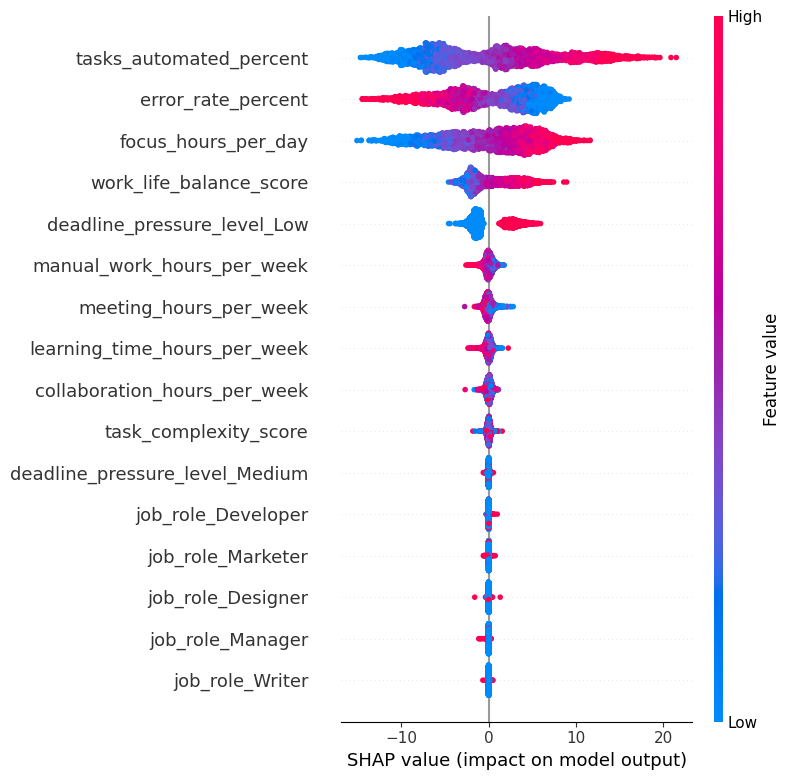

In [74]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)

### **Local Evaluation**

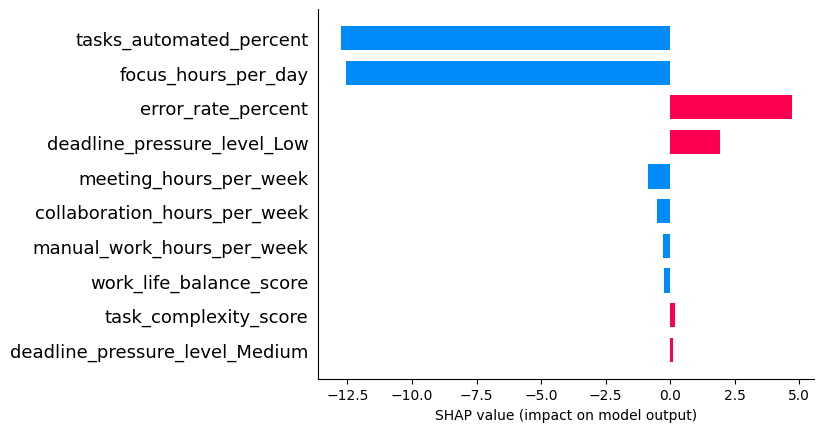

Esempio 0: Previsione = 44.65, Reale = 45.50


In [75]:
# Trasforma il test set
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

# Scegli un esempio (cambia idx per altri)
idx = 0
sample = X_test_transformed[idx:idx+1]

# Calcola SHAP per questo esempio
shap_values_single = explainer.shap_values(sample)

# Bar plot statico per spiegare la previsione (più semplice da visualizzare)
shap.bar_plot(shap_values_single[0], feature_names=feature_names, max_display=10)

# Mostra anche la previsione e il valore reale
pred = model.predict(X_test.iloc[idx:idx+1])
real = y_test.iloc[idx]
print(f"Esempio {idx}: Previsione = {pred[0]:.2f}, Reale = {real:.2f}")

The SHAP (SHapley Additive exPlanations) bar plot visualizes the contribution of each feature to the model's prediction for a **single example** (in this case, the first test sample, idx=0).

**Key Elements:**

- **Base Value:** The average prediction across all training data (around 45-50 in this case). This is the starting point before considering any features.

- **SHAP Values (Bars):** Each bar represents how much a specific feature pushes the prediction away from the base value.
    - **Positive Bars (Red):** Features that **increase** the prediction (e.g., high work_life_balance_score might add +2 to the score).
    - **Negative Bars (Blue):** Features that **decrease** the prediction (e.g., high error_rate_percent might subtract -1.5).

- **Bar Length:** Indicates the magnitude of the impact. Longer bars mean the feature has a stronger influence on this prediction.

- **Feature Names:** Listed on the y-axis, showing the top 10 most impactful features for this example.+

**How to Interpret:**

- The **sum of all SHAP values + base value = final prediction** (44.65 in this example).

- This plot explains **why** the model predicted 44.65 instead of the base value, making the decision transparent.

- For instance, if "focus_hours_per_day" has a large positive bar, it means higher focus hours significantly boosted the productivity score for this employee.

**Comparison with Real Value:**

Predicted: 44.65
Real: 45.50
The model is close, and SHAP shows which features drove this result.
This individual explanation complements the global SHAP summary plot, providing insights into specific cases for better model trust and debugging.